In [546]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [547]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [548]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [549]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (129660013714)>


In [550]:
lc = 0.3

# Initialize Gmsh
import gmsh
import sys

gmsh.initialize()
gmsh.model.add("fused_shapes")
occ = gmsh.model.occ

# --- Rectangles ---
rect1 = occ.addRectangle(0, 0, 0, 15, 4)

# --- Triangle beside rect2 ---
p1 = occ.addPoint(5, 4, 0)
p2 = occ.addPoint(15, 4, 0)
p3 = occ.addPoint(15, 8, 0)
p4 = occ.addPoint(12, 8, 0)
l5 = occ.addLine(p1, p2)
l6 = occ.addLine(p2, p3)
l7 = occ.addLine(p3, p4)
l8 = occ.addLine(p4, p1)
triangle_loop = occ.addCurveLoop([l5, l6, l7, l8])
triangle = occ.addPlaneSurface([triangle_loop])

# --- Fragment everything ---
fused = occ.fragment([(2, rect1)], [(2, triangle)])

# --- Synchronize ---
occ.synchronize()

# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support")

gmsh.model.addPhysicalGroup(1, [2], tag=202)
gmsh.model.setPhysicalName(1, 202, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=203)
gmsh.model.setPhysicalName(1, 203, "right_top_support")

gmsh.model.addPhysicalGroup(1, [5], tag=204)
gmsh.model.setPhysicalName(1, 204, "left_support")

gmsh.model.addPhysicalGroup(1, [l7], tag=205)
gmsh.model.setPhysicalName(1, 205, "loadings")

# --- Synchronize ---
occ.synchronize()
# --- Points to embed ---
embed_coords = [
    (11.2520, 6.2098, 0),
    (10.1450, 5.2189, 0),
    (8.6716, 4.1979, 0),
    (11.5000, 6.5000, 0),
    (11.0000, 5.5000, 0),
    (10.0000, 5.0000, 0),
    (9.0000, 3.5000, 0),
    (7.0000, 3.5000, 0),
    (6.0000, 3.0000, 0),
    (5.5000, 3.0000, 0),
    (5.0000, 2.5000, 0),
]

embed_pts_occ = [occ.addPoint(x, y, z, lc) for x, y, z in embed_coords]

# --- Synchronize ---
occ.synchronize()

# --- Embed points in triangle ---
# Helper to match 3D coordinates approximately
def coords_close(c1, c2, tol=1e-4):
    return all(isclose(a, b, abs_tol=tol) for a, b in zip(c1, c2))

# Get all 2D surfaces
surfaces = gmsh.model.getEntities(2)

# Build mapping of surface tag to bounding box
surface_boxes = {}
for dim, tag in surfaces:
    box = gmsh.model.getBoundingBox(dim, tag)
    surface_boxes[tag] = box

# Embed points into correct surface
for pt in embed_pts_occ:
    coord = gmsh.model.getValue(0, pt, [])
    x, y, z = coord

    for surf_tag, (xmin, ymin, zmin, xmax, ymax, zmax) in surface_boxes.items():
        if xmin <= x <= xmax and ymin <= y <= ymax:
            gmsh.model.mesh.embed(0, [pt], 2, surf_tag)
            print(f"Embedded point ({x:.3f}, {y:.3f}) to surface {surf_tag}")
            break

# --- Local refinement using Ball fields ---
ball_fields = []
for x, y, z in embed_coords:
    fid = gmsh.model.mesh.field.add("Ball")
    gmsh.model.mesh.field.setNumber(fid, "XCenter", x)
    gmsh.model.mesh.field.setNumber(fid, "YCenter", y)
    gmsh.model.mesh.field.setNumber(fid, "ZCenter", z)
    gmsh.model.mesh.field.setNumber(fid, "Radius", 1.0)
    gmsh.model.mesh.field.setNumber(fid, "VIn", 0.3)
    gmsh.model.mesh.field.setNumber(fid, "VOut", 0.5)
    ball_fields.append(fid)

# Combine Ball fields
min_field = gmsh.model.mesh.field.add("Min")
gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", ball_fields)
gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

# --- Mesh settings ---
gmsh.model.mesh.setSize(gmsh.model.getEntities(0), 0.5)


gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_top")

# --- Generate mesh ---
gmsh.model.mesh.generate(2)
#gmsh.write("slope_b.msh")
#gmsh.fltk.run()
#gmsh.finalize()


Embedded point (11.252, 6.210) to surface 2
Embedded point (10.145, 5.219) to surface 2
Embedded point (8.672, 4.198) to surface 2
Embedded point (11.500, 6.500) to surface 2
Embedded point (11.000, 5.500) to surface 2
Embedded point (10.000, 5.000) to surface 2
Embedded point (9.000, 3.500) to surface 1
Embedded point (7.000, 3.500) to surface 1
Embedded point (6.000, 3.000) to surface 1
Embedded point (5.500, 3.000) to surface 1
Embedded point (5.000, 2.500) to surface 1


In [551]:
# Initialize GMSH to OpenSeesPy converter with 3D model and 3 degrees of freedom per node
GMSH2OPS = opst.pre.Gmsh2OPS(ndm=2, ndf=2)
# Read the saved .msh file generated by GMSH
GMSH2OPS.read_gmsh_data()
# Finalize and close, must after GMSH2OPS.read_gmsh_data()
gmsh.finalize()  # !!!!!!!!!!!!!!!

Info:: Geometry Information >>>
28 Entities: 18 Point; 8 Curves; 2 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
7 Physical Groups.
Physical Group names: ['bottom_support', 'right_bot_support', 'right_top_support', 'left_support', 'loadings', 'soil_bot', 'soil_top']

Info:: Mesh Information >>>
668 Nodes; MaxNodeTag 668; MinNodeTag 1.
1378 Elements; MaxEleTag 1378; MinEleTag 1.



In [552]:
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

ops.wipe()
# Initialize a basic 3D model with 3 degrees of freedom per node
ops.model("basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            1.8*UNIT.ton / UNIT.m3, #rho ton /m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis

soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m


In [553]:
GMSH2OPS.create_node_cmds()

# Create OpenSeesPy element commands for specific entities
# ASDShellT3 elements (3-node shell elements)
#
ele_tags = GMSH2OPS.create_element_cmds(
    ops_ele_type="tri31",  # OpenSeesPy element type
    ops_ele_args=[soil_thickness, etype, soil_mat_tag
                  ],  # Additional arguments for the element (e.g., mat tag)
    # Dimension-entity tags to specify which elements to create
    physical_group_names=["soil_bot"],
)

In [554]:
ele_tags = GMSH2OPS.create_element_cmds(
    ops_ele_type="tri31",  # OpenSeesPy element type
    ops_ele_args=[soil_thickness, etype, soil_mat_tag
                  ],  # Additional arguments for the element (e.g., mat tag)
    # Dimension-entity tags to specify which elements to create
    physical_group_names=["soil_top"],
)

In [555]:
GMSH2OPS.create_fix_cmds(
    physical_group_names=["left_support"], dofs=[*fixXonly]
)

[89, 90, 91, 92, 93, 94, 95]

In [556]:
GMSH2OPS.create_fix_cmds(
    physical_group_names=["right_top_support"], dofs=[*fixXonly]
)

[96, 97, 98, 99, 100, 101, 102]

In [557]:
GMSH2OPS.create_fix_cmds(
    physical_group_names=["right_bot_support"], dofs=[*fixXonly]
)

[48, 49, 50, 51, 52, 53, 54]

In [558]:
GMSH2OPS.create_fix_cmds(
    physical_group_names=["bottom_support"], dofs=[*fixYonly]
)

[19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47]

In [559]:
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.fix(5, 1, 0)
ops.fix(6, 1, 0)

In [560]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

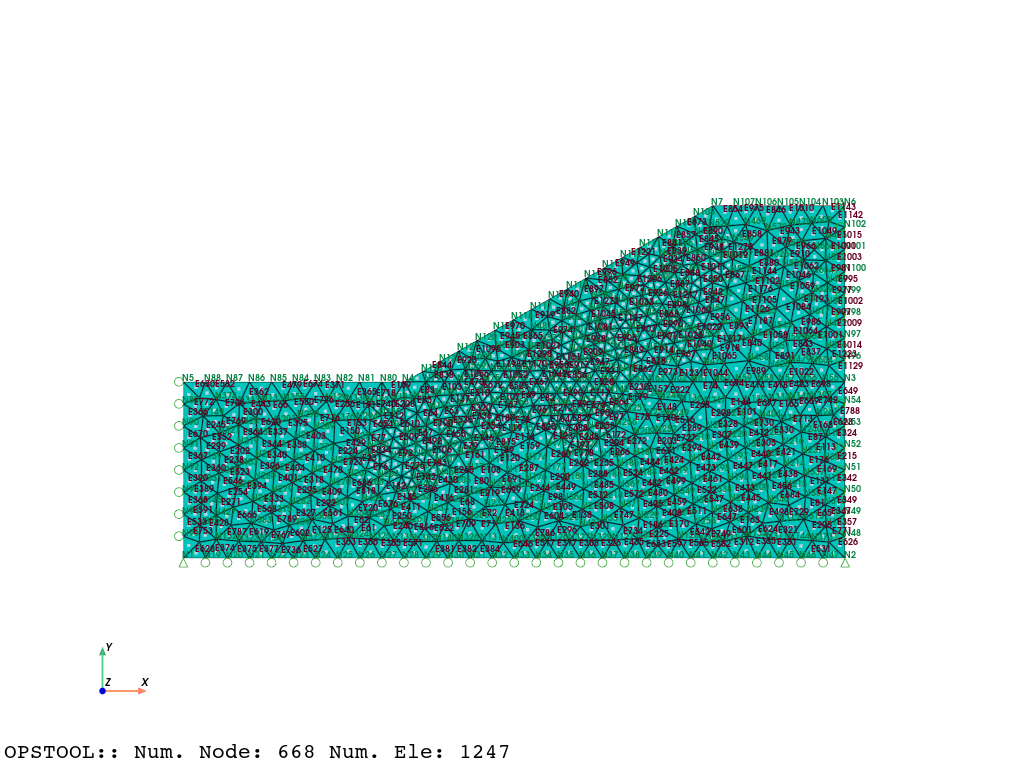

In [561]:
OPSVIS = opst.vis.pyvista
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [562]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [563]:
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [564]:
def analysis_steps(nsteps=4):
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [565]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

In [566]:
PN_1 = 5000*UNIT.N
print(PN_1)
ops.load(107, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

5.0


In [567]:
PN_1 = 5000*UNIT.N
print(PN_1)
ops.load(106, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

5.0


In [568]:
PN_1 = 5000*UNIT.N
print(PN_1)
ops.load(105, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

5.0


In [569]:
PN_1 = 5000*UNIT.N
print(PN_1)
ops.load(104, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

5.0


In [570]:
PN_1 = 5000*UNIT.N
print(PN_1)
ops.load(103, 0, -PN_1)
ops.analyze(1)
analysis_steps(nsteps=10)

5.0


In [571]:
fig = opst.vis.plotly.plot_model(show_ele_loads=True, show_nodal_loads=True, load_scale=2)
fig.show()

In [572]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [573]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

In [574]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", title_font_size=12, notebook=True)


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

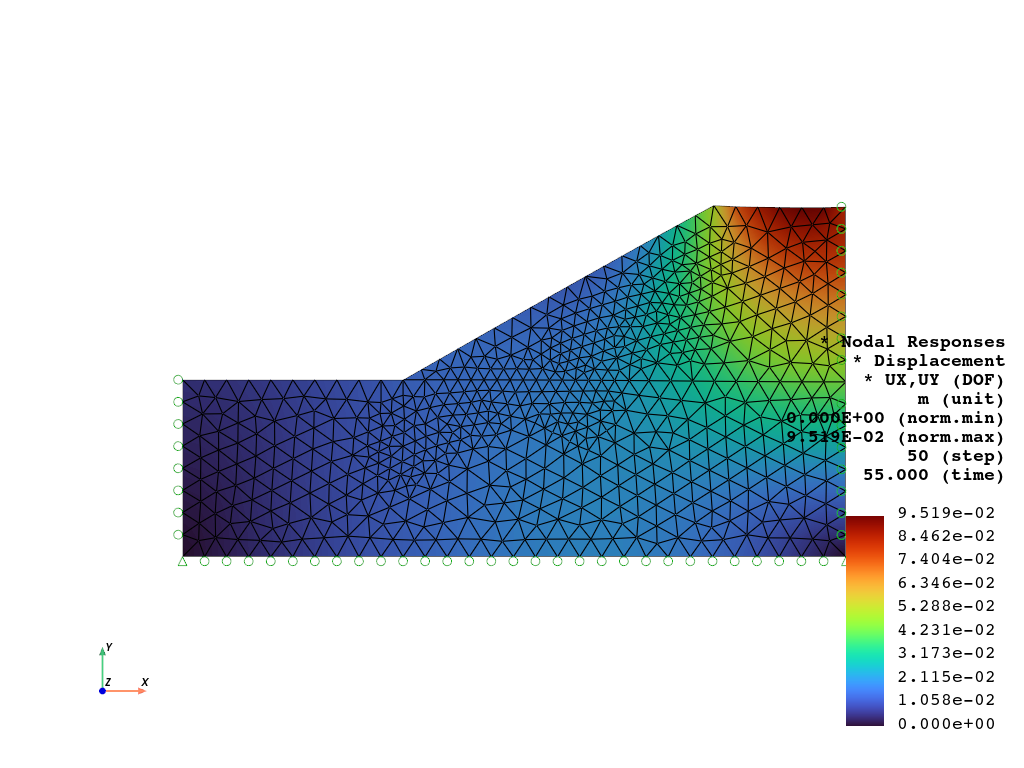

In [575]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=1,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

In [576]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=1,
    scale=0.0001,
    savefig="slope_b.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to slope_b.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

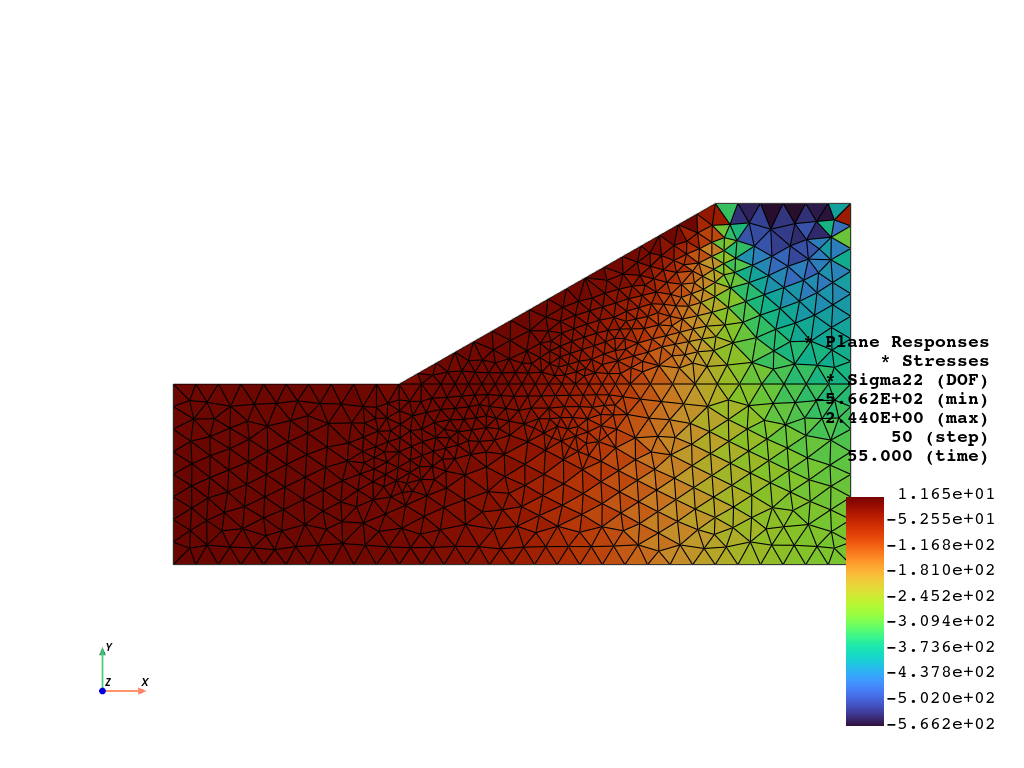

In [577]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22",bc_scale = 0.001,defo_scale = 0.001
).show(jupyter_backend="jupyterlab")

In [578]:
NodalResp = opst.post.get_nodal_responses(odb_tag=1)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-1.nc ...

In [579]:
time = NodalResp.time
disp = NodalResp["disp"].sel(nodeTags=7, DOFs="UY")

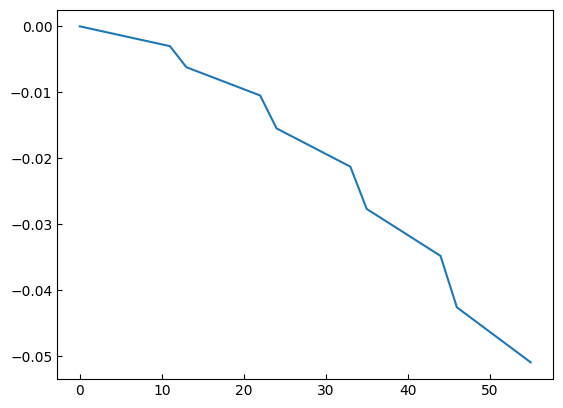

In [580]:
plt.plot(time, disp)
plt.show()